In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from math import sqrt

# Install and upgrade xgboost if needed (run only once and restart kernel if you do this)
!pip install --upgrade xgboost
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2



data = pd.read_csv('/kaggle/input/newdata/ProductionDataAll - Copy.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 10.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3
Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 83.1 MB/s eta 0:00:00:00:010:01


In [2]:
# Check for missing values and handle them appropriately
data['Temperature'] = data['Temperature'].interpolate()

In [3]:
#Convert the Date column to datetime and extract additional features like year, month, and day if required
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

In [4]:
#Separate the dataset into individual time series for each country
countries = data['Country'].unique()

In [5]:
# Add seasonality features (e.g., sine and cosine transformations of month)
data['sin_month'] = np.sin(2 * np.pi * data['Month'] / 12)
data['cos_month'] = np.cos(2 * np.pi * data['Month'] / 12)

In [6]:
# Feature Engineering (with adjustments)
for lag in range(1, 13):
    data[f'lag_{lag}'] = data.groupby('Country')['Temperature'].shift(lag)
data['rolling_mean_12'] = data.groupby('Country')['Temperature'].transform(lambda x: x.rolling(window=12,center=True).mean())
data['rolling_std_12'] = data.groupby('Country')['Temperature'].transform(lambda x: x.rolling(window=12,center=True).std())

data = data.dropna()

In [7]:
features = [col for col in data.columns if col not in ['Date', 'Temperature', 'Country', 'Year']]
# Separate features and target for scaling
X = data[features]
y = data['Temperature']

In [8]:
# Scale features (Important for XGBoost)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Splitting data (consider using time-based split for better evaluation)
train = data[data['Year'] <= 2019]
test = data[data['Year'] > 2019]
X_train = train[features]
y_train = train['Temperature']
X_test = test[features]
y_test = test['Temperature']

In [10]:
X_train_scaled = scaler.transform(X_train) # Use the same scaler fitted on the entire dataset
X_test_scaled = scaler.transform(X_test)

In [11]:
# Model training
model = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=7, min_child_weight=1, subsample=0.8, colsample_bytree=0.8, random_state=42) # Tuning parameters
model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [12]:
# Predictions and Evaluation
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse=sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAE: {mae}, RMSE: {rmse}, MAPE: {mape}',)

MAE: 0.6232441233548252, RMSE: 1.0409806695956092, MAPE: 0.03187260250099297


In [13]:
# Retrain the model on the entire dataset
model.fit(X_scaled, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [14]:
# Future Predictions (modified)
future_dates = pd.date_range(start='2025-01-01', periods=60, freq='M')
future_predictions = []

for country in countries:
    last_data_point = data[data['Country'] == country].iloc[-1]
    future_df = pd.DataFrame({
        'Date': future_dates,
        'Year': future_dates.year,
        'Month': future_dates.month,
        'Day': 1, # arbitrary as we are at a monthly level
        'DayOfYear': future_dates.dayofyear,
        'Country': country,
        'sin_month': np.sin(2 * np.pi * future_dates.month / 12),
        'cos_month': np.cos(2 * np.pi * future_dates.month / 12),
    })
    for lag in range(1, 13):
        future_df[f'lag_{lag}'] = last_data_point[f'lag_{lag}']

    future_df['rolling_mean_12'] = last_data_point['rolling_mean_12']
    future_df['rolling_std_12'] = last_data_point['rolling_std_12']

    future_df_scaled = scaler.transform(future_df[features])
    future_df['Temperature'] = model.predict(future_df_scaled)
    future_predictions.append(future_df)

future_predictions_df = pd.concat(future_predictions)
#future_predictions_df['Date] to first day of the month)
future_predictions_df['Date'] = future_predictions_df['Date'].dt.to_period('M').dt.to_timestamp()

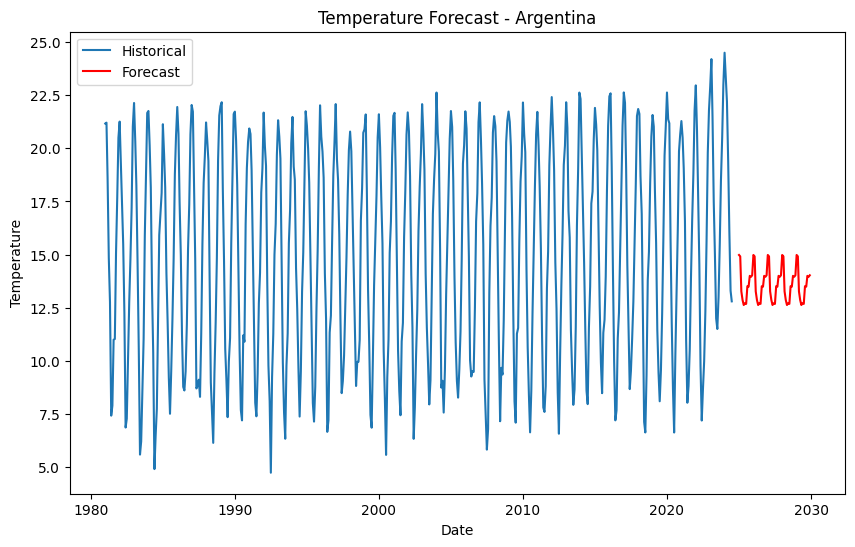

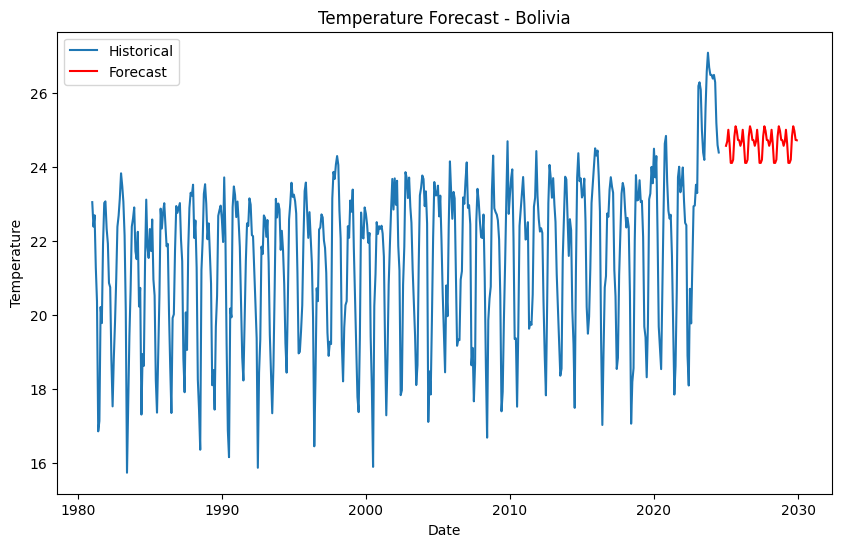

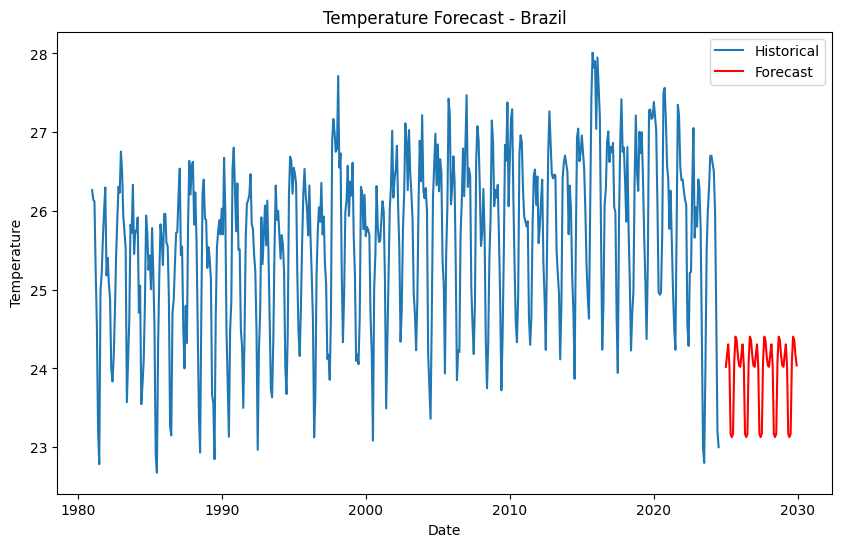

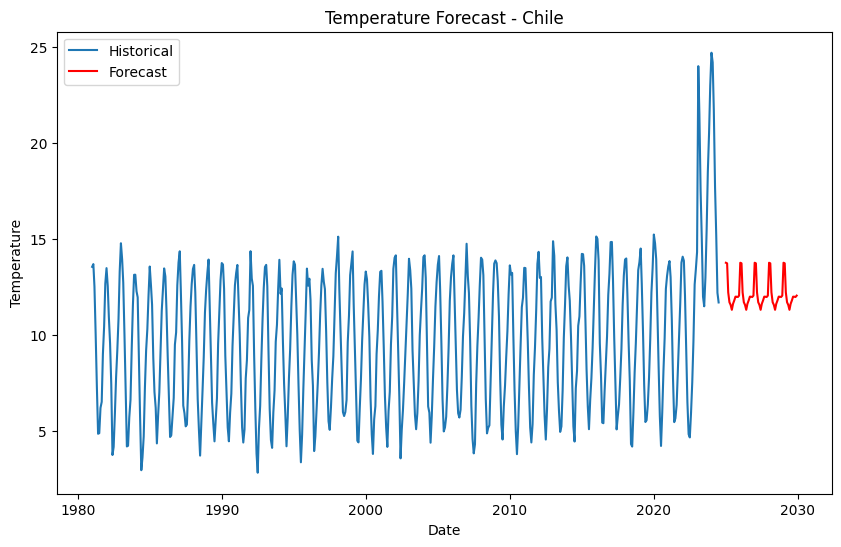

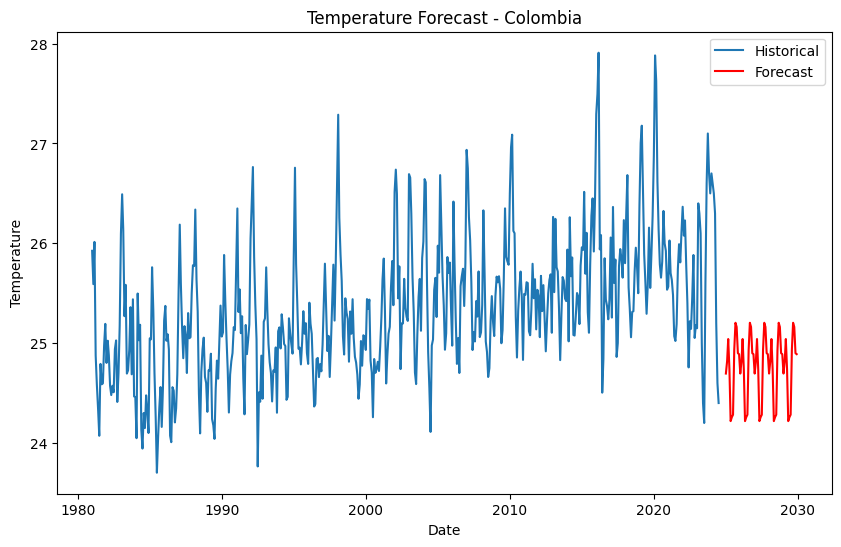

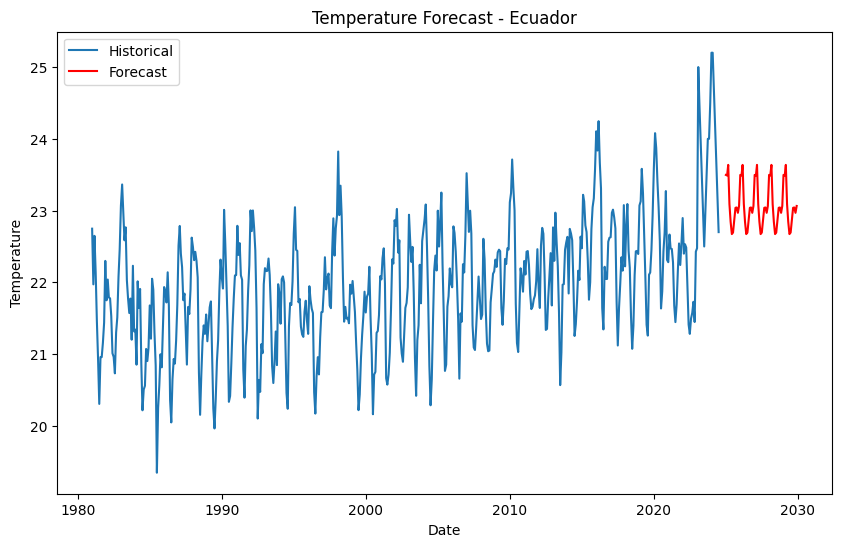

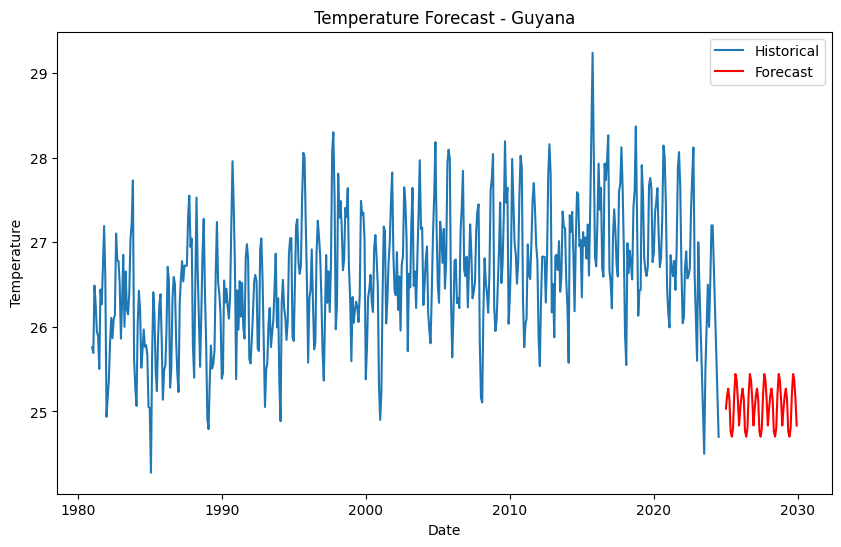

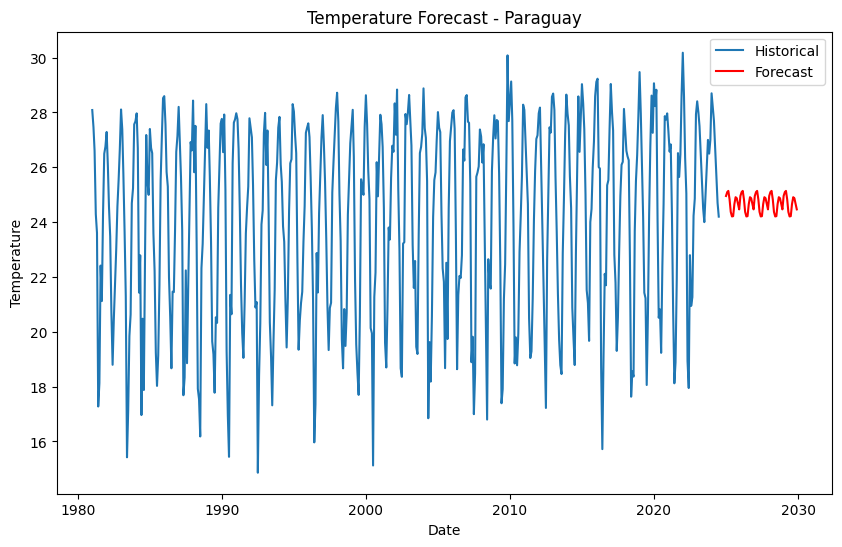

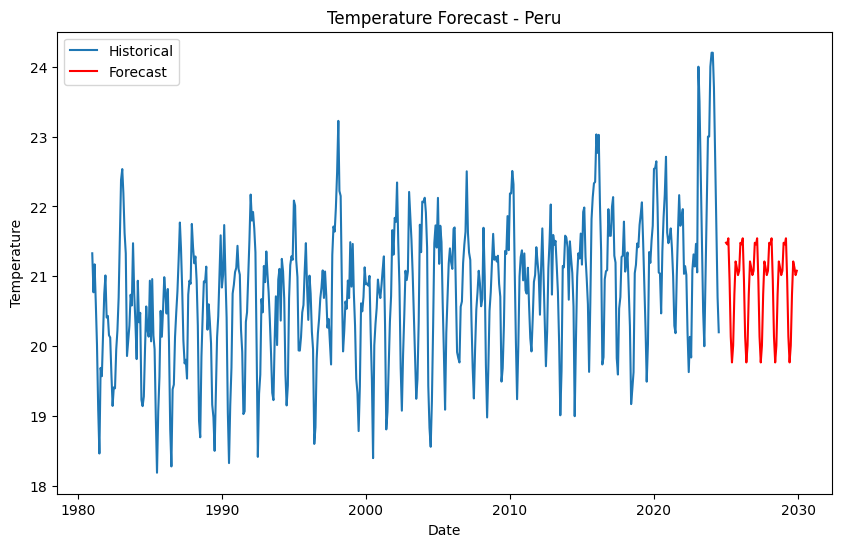

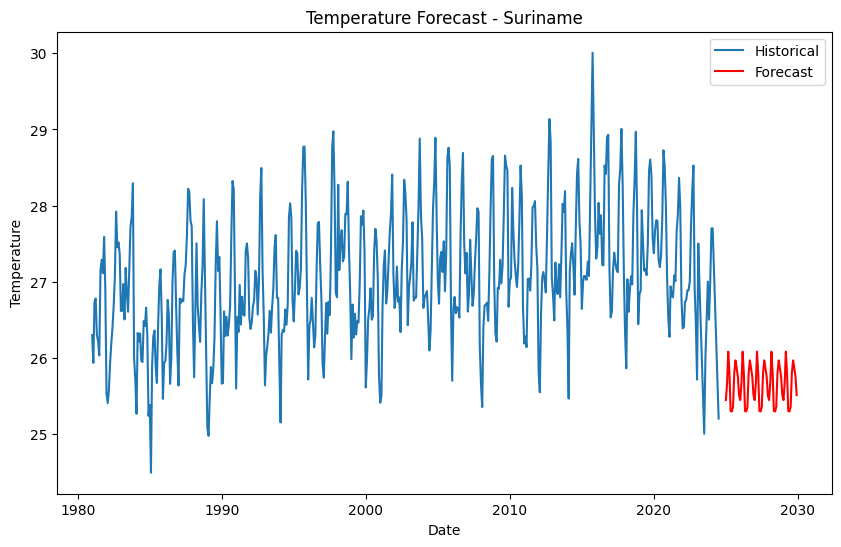

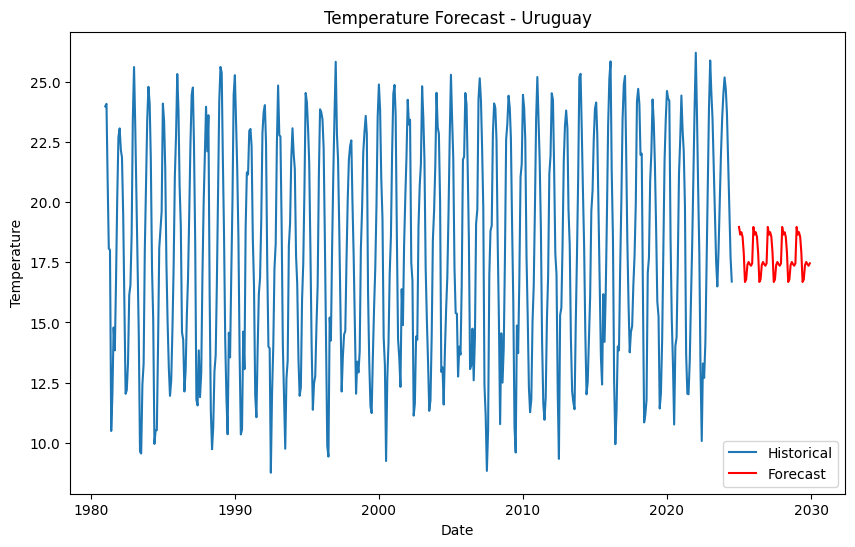

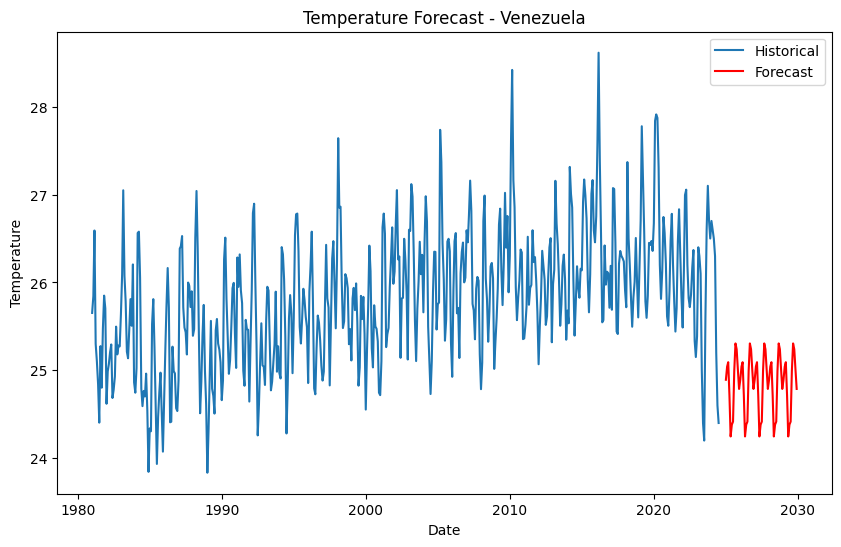

In [15]:
# Plotting and saving
for country in countries:
    country_data = data[data['Country'] == country]
    forecast = future_predictions_df[future_predictions_df['Country'] == country]
    plt.figure(figsize=(10, 6))
    plt.xlabel('Date')
    plt.ylabel('Temperature')
    plt.plot(country_data['Date'], country_data['Temperature'], label='Historical')
    plt.plot(forecast['Date'], forecast['Temperature'], label='Forecast', color='r')
    plt.title(f'Temperature Forecast - {country}')
    plt.legend()
    plt.show()

In [16]:
future_predictions_df = future_predictions_df[['Country', 'Date', 'Temperature']]
future_predictions_df.to_csv('XGBoost Data.csv')